# Introdução

### Descrição do Projeto

Você trabalha para a loja online Ice, que vende videogames no mundo todo. As avaliações de usuários e especialistas, gêneros, plataformas (por exemplo, Xbox ou PlayStation) e dados históricos sobre vendas de jogos estão disponíveis em fontes abertas. Você precisa identificar padrões que determinam se um jogo tem sucesso ou não. Isso vai permitir que você identifique possíveis sucessos e planeje campanhas publicitárias.

Os dados disponibilizados remontam a 2016. Vamos imaginar que estamos em dezembro de 2016 e você está planejando uma campanha para 2017.

O importante é ganhar experiência trabalhando com dados. Não importa se você está prevendo as vendas de 2017 com base nos dados de 2016 ou as vendas de 2027 com base nos dados de 2026.

O conjunto de dados contém uma coluna de "rating" (classificação) que armazena a classificação ESRB de cada jogo. O Entertainment Software Rating Board avalia o conteúdo de um jogo e atribui uma classificação etária, como Teen (Adolescente) ou Mature (Adulto).

<br><br>

# Etapa 1 - Estudo das Informações Gerais

Nesta etapa faremos uma análise da base de dados fornecida pela loja online Ice. A base disponibilizada remonta a 2016.

O que será feito e analisado nesta etapa:

- Importação da Biblioteca pandas e leitura do arquivo;
- Verificação geral da base de dados;
- Formatação dos dados;
- Existência de valores duplicados, nulos, ausentes;

Ao final, serão apresentadas as informações identificadas, bem como a relação das soluções propostas para cada erro detectado.

Obs.: Em cada célula 'code' haverá comentários explicando o que a linha ou bloco de código irá executar.



In [3]:
# Importação de Bibliotecas utilizadas

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats

In [4]:
# Leitura do DataFrame

games = pd.read_csv('games.csv')

In [5]:
# Informações gerais sobre o DataFrame

games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [6]:
# Impressão dos 15 primeiros dados para  visualização e análise

print(games.head(15))

                           Name Platform  Year_of_Release         Genre  \
0                    Wii Sports      Wii           2006.0        Sports   
1             Super Mario Bros.      NES           1985.0      Platform   
2                Mario Kart Wii      Wii           2008.0        Racing   
3             Wii Sports Resort      Wii           2009.0        Sports   
4      Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing   
5                        Tetris       GB           1989.0        Puzzle   
6         New Super Mario Bros.       DS           2006.0      Platform   
7                      Wii Play      Wii           2006.0          Misc   
8     New Super Mario Bros. Wii      Wii           2009.0      Platform   
9                     Duck Hunt      NES           1984.0       Shooter   
10                   Nintendogs       DS           2005.0    Simulation   
11                Mario Kart DS       DS           2005.0        Racing   
12  Pokemon Gold/Pokemon 

In [7]:
# Impressão dos 15 últimos dados para  visualização e análise

print(games.tail(15))

                                                    Name Platform  \
16700                           Mezase!! Tsuri Master DS       DS   
16701  Eiyuu Densetsu: Sora no Kiseki Material Collec...      PSP   
16702                            STORM: Frontline Nation       PC   
16703                                   Strawberry Nauts      PSV   
16704                                           Plushees       DS   
16705                                            15 Days       PC   
16706                      Men in Black II: Alien Escape       GC   
16707                                   Aiyoku no Eustia      PSV   
16708                 Woody Woodpecker in Crazy Castle 5      GBA   
16709   SCORE International Baja 1000: The Official Game      PS2   
16710                      Samurai Warriors: Sanada Maru      PS3   
16711                                   LMA Manager 2007     X360   
16712                            Haitaka no Psychedelica      PSV   
16713                             

In [8]:
# Impressão aleatória dos dados para  visualização e análise

print(games.sample(15))

                                                 Name Platform  \
9192                           Power Pro Kun Pocket 8       DS   
1451                                   Chrono Trigger       DS   
4951   SpongeBob vs The Big One: Beach Party Cook Off       DS   
5231                          Tiger Woods PGA Tour 09      PSP   
13891                             The Sims 4: Spa Day       PC   
3463                Prince of Persia: The Two Thrones       XB   
16103                Period Cube: Torikago no Amadeus      PSV   
8441              Leisure Suit Larry: Magna Cum Laude       XB   
4617                    Cabela's Legendary Adventures      PS2   
12283                                187: Ride or Die       XB   
4463                               Karaoke Revolution      Wii   
8150                       Twisted Metal: Small Brawl       PS   
1724                PokéPark Wii: Pikachu's Adventure      Wii   
139                                            Driver       PS   
7229      

### Análise da Etapa 1

Durante a análise preliminar, foi identificado que os nomes das colunas apresentam variação entre letras maiúsculas e minúsculas, além da existência de colunas com dados incompletos. Constatou-se também a necessidade de adequação dos tipos de dados em determinadas colunas, com o objetivo de otimizar a consistência e a eficiência da análise.

<br><br>

# Etapa 2 - Preparação dos Dados

Nesta etapa, serão realizadas as devidas correções e o tratamento dos dados identificados e listados na fase anterior. O processo será conduzido com atenção para garantir que as alterações ou exclusões efetuadas não comprometam a integridade e a consistência da análise final. Serão executados ajustes nos nomes das colunas, conversões de tipos de dados, tratamento de valores ausentes ou nulos, além da criação de novas colunas, quando necessário, visando aprimorar a qualidade e a estrutura do conjunto de dados.

Verificação e substituição dos nomes das colunas (transformando tudo em minúsculos).



In [9]:
# Verificar os nomes das colunas

games.columns

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'NA_sales', 'EU_sales',
       'JP_sales', 'Other_sales', 'Critic_Score', 'User_Score', 'Rating'],
      dtype='object')

In [10]:
# Correção dos nomes das colunas. Todas em minusculas.

new_names_columns = []

for old_name in games.columns:
    name_lowered = old_name.lower()
    new_names_columns.append(name_lowered)

games.columns = new_names_columns

print(games.columns)

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')


**Conversão dos dados para os tipos necessários**

In [11]:
# Conversão das colunas 'platform', 'genre', 'year_of_release'

games['platform'] = games['platform'].astype('category')

games['genre'] = games['genre'].astype('category')

games['rating'] = games['rating'].astype('category')

games['year_of_release'] = games['year_of_release'].astype('Int64')

games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   name             16713 non-null  object  
 1   platform         16715 non-null  category
 2   year_of_release  16446 non-null  Int64   
 3   genre            16713 non-null  category
 4   na_sales         16715 non-null  float64 
 5   eu_sales         16715 non-null  float64 
 6   jp_sales         16715 non-null  float64 
 7   other_sales      16715 non-null  float64 
 8   critic_score     8137 non-null   float64 
 9   user_score       10014 non-null  object  
 10  rating           9949 non-null   category
dtypes: Int64(1), category(3), float64(5), object(2)
memory usage: 1.1+ MB


**Justificativa das conversões realizadas**

As colunas 'platform', 'genre' e 'rating' foram convertidas para o tipo category. Além de representarem variáveis de natureza categórica, essa alteração contribui para a otimização da memória e facilita a realização de análises estatísticas e comparativas.

As colunas 'year_of_release' e 'critic_score' foram convertidas do tipo float para Int64. No caso de year_of_release, a conversão se justifica por se tratar de um dado que representa um ano, portanto, naturalmente inteiro. Já para 'critic_score', verificou-se que, apesar de originalmente armazenada como float, não havia registros com casas decimais, tornando a conversão apropriada.

Optou-se especificamente pelo tipo Int64 em razão da presença de valores nulos e ausentes, uma vez que esse tipo permite o tratamento eficiente de dados numéricos com valores faltantes, mantendo a consistência e a precisão das análises subsequentes.

<br><br>

**Tratamento valores nulos e ausentes**

Se necessário, decida como lidar com valores ausentes:

Explique sua abordagem ao preencher valores ausentes ou ao deixá-los em branco.
Na sua opinião, por que os valores estão ausentes? Dê possíveis razões.
Preste atenção à abreviação TBD (que significa "to be determined", ou "a ser determinado"). Especifique como pretende lidar com esses casos.


In [12]:
# Verificação de valores ausentes, nulos e duplicados

print(games.isna().sum())
print()
print('Quantidade de valores duplicados: ', games.duplicated().sum())

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
rating             6766
dtype: int64

Quantidade de valores duplicados:  0


**justificativa sobre o tratamentos de valores ausentes**

Para o tratamento dos valores ausentes, serão adotadas as seguintes estratégias:

Colunas 'name' e 'genre': as linhas que contêm valores ausentes serão excluídas, uma vez que o impacto sobre o volume total de dados é mínimo.

- Coluna 'year_of_release': embora a exclusão dessas linhas também representasse um impacto reduzido (aproximadamente 1,6% dos registros), o problema foi solucionado durante a conversão de tipo. A utilização do tipo Int64 permite o tratamento eficiente de valores numéricos, mesmo na presença de ausências, sem comprometer a consistência dos dados.

- Coluna 'critic_score': os valores ausentes serão mantidos, considerando-se a elevada proporção de registros sem avaliação. A conversão para o tipo Int64 contribui para a adequada manipulação e leitura dessa variável.

- Coluna 'user_score': os valores representados por 'TBD' (To Be Determined) serão substituídos por 'NaN', padronizando o tratamento de dados ausentes e facilitando a posterior conversão para tipo numérico.

- Coluna 'rating': os valores ausentes serão preenchidos com a categoria 'Unknown', dado o número expressivo de registros sem informação, evitando a perda de dados e garantindo maior uniformidade à base.

<br><br>

**Execução das estratégias de tratamento**


In [13]:
# Exclusão dos valores ausentes das colunas 'name' e 'genre'.

print(games['name'].isna().sum())
print(games['genre'].isna().sum())
games = games.dropna(subset=['name', 'genre']).reset_index(drop=True)
print()
print('Coluna [name] ', games['name'].isna().sum())
print('Coluna [genre] ', games['genre'].isna().sum())

2
2

Coluna [name]  0
Coluna [genre]  0


In [14]:
# substituição dos valores da coluna 'user_score' de 'TBD'para 'NaN'.

games['user_score'] = games['user_score'].replace('tbd', np.nan)

print(games['user_score'].unique())

['8' nan '8.3' '8.5' '6.6' '8.4' '8.6' '7.7' '6.3' '7.4' '8.2' '9' '7.9'
 '8.1' '8.7' '7.1' '3.4' '5.3' '4.8' '3.2' '8.9' '6.4' '7.8' '7.5' '2.6'
 '7.2' '9.2' '7' '7.3' '4.3' '7.6' '5.7' '5' '9.1' '6.5' '8.8' '6.9' '9.4'
 '6.8' '6.1' '6.7' '5.4' '4' '4.9' '4.5' '9.3' '6.2' '4.2' '6' '3.7' '4.1'
 '5.8' '5.6' '5.5' '4.4' '4.6' '5.9' '3.9' '3.1' '2.9' '5.2' '3.3' '4.7'
 '5.1' '3.5' '2.5' '1.9' '3' '2.7' '2.2' '2' '9.5' '2.1' '3.6' '2.8' '1.8'
 '3.8' '0' '1.6' '9.6' '2.4' '1.7' '1.1' '0.3' '1.5' '0.7' '1.2' '2.3'
 '0.5' '1.3' '0.2' '0.6' '1.4' '0.9' '1' '9.7']


In [15]:
games['user_score'] = games['user_score'].astype('float')
games.info()
print(games['user_score'].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16713 entries, 0 to 16712
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   name             16713 non-null  object  
 1   platform         16713 non-null  category
 2   year_of_release  16444 non-null  Int64   
 3   genre            16713 non-null  category
 4   na_sales         16713 non-null  float64 
 5   eu_sales         16713 non-null  float64 
 6   jp_sales         16713 non-null  float64 
 7   other_sales      16713 non-null  float64 
 8   critic_score     8137 non-null   float64 
 9   user_score       7590 non-null   float64 
 10  rating           9949 non-null   category
dtypes: Int64(1), category(3), float64(6), object(1)
memory usage: 1.1+ MB
[8.  nan 8.3 8.5 6.6 8.4 8.6 7.7 6.3 7.4 8.2 9.  7.9 8.1 8.7 7.1 3.4 5.3
 4.8 3.2 8.9 6.4 7.8 7.5 2.6 7.2 9.2 7.  7.3 4.3 7.6 5.7 5.  9.1 6.5 8.8
 6.9 9.4 6.8 6.1 6.7 5.4 4.  4.9 4.5 9.3 6.2 4.2 6.  3.7 4.

Após a substituição dos valores de 'TBD' para 'NaN' os dados ficaram em uma condição propícia a conversão de tipo para float.

In [16]:
# Preenchimento dos valores ausentes da coluna 'rating' pela categoria 'Unknown'.

# Como a coluna é do tipo 'category' precisamos criar a categoria 'Unknown'
games['rating'] = games['rating'].cat.add_categories(['Unknown'])

# Logo após realiza-se a substituição
games['rating'] = games['rating'].fillna('Unknown')

# Verificando o resultado
print(games['rating'].unique())

['E', 'Unknown', 'M', 'T', 'E10+', 'K-A', 'AO', 'EC', 'RP']
Categories (9, object): ['AO', 'E', 'E10+', 'EC', ..., 'M', 'RP', 'T', 'Unknown']


Calcule o total de vendas (a soma das vendas em todas as regiões) para cada jogo e coloque esses valores em uma coluna separada.

In [17]:
# Total de vendas por jogo em todas as regiões.

games['total_sales'] = games[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum(axis=1)
print(games['total_sales'])

games.info()

0        82.54
1        40.24
2        35.52
3        32.77
4        31.38
         ...  
16708     0.01
16709     0.01
16710     0.01
16711     0.01
16712     0.01
Name: total_sales, Length: 16713, dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16713 entries, 0 to 16712
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   name             16713 non-null  object  
 1   platform         16713 non-null  category
 2   year_of_release  16444 non-null  Int64   
 3   genre            16713 non-null  category
 4   na_sales         16713 non-null  float64 
 5   eu_sales         16713 non-null  float64 
 6   jp_sales         16713 non-null  float64 
 7   other_sales      16713 non-null  float64 
 8   critic_score     8137 non-null   float64 
 9   user_score       7590 non-null   float64 
 10  rating           16713 non-null  category
 11  total_sales      16713 non-null  float64 
dtypes: Int64(1), c

# Etapa 3 - Análise Exploratória dos Dados

**Lançamentos de jogos por ano**

Veja quantos jogos foram lançados a cada ano. Os dados de cada período são significativos?

In [18]:
games_por_ano = games.groupby(['year_of_release'])
resultado = games_por_ano['name'].count()

print(resultado)

year_of_release
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      60
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: name, dtype: int64


<Axes: title={'center': 'Quantidades de Jogos Lançados Por Ano'}, xlabel='Anos', ylabel='Quantidade'>

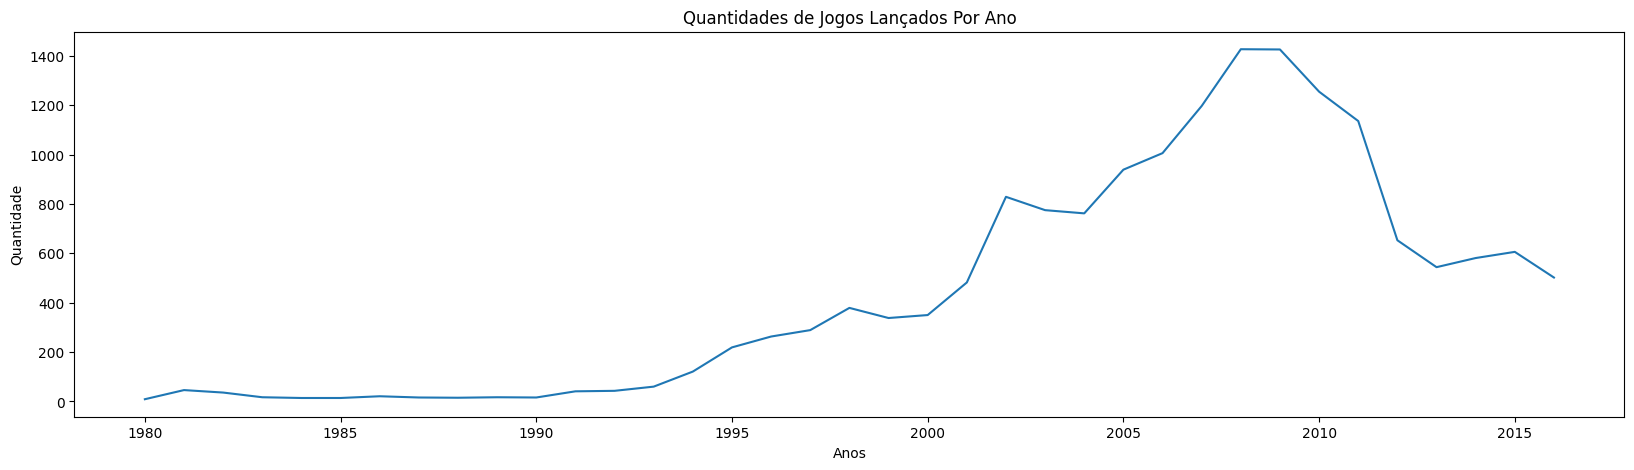

In [19]:
resultado.plot(title='Quantidades de Jogos Lançados Por Ano',
               xlabel='Anos',
               ylabel='Quantidade',
               figsize=[20, 5]
               
              )

**Análise de quantidade de lançamentos por ano**

De 1993 para os anos anteriores, observa-se uma quantidade pouco expressiva de lançamentos, o que indica uma amostragem limitada e, portanto, de menor relevância estatística. Entre 1993 e 2001, verifica-se um crescimento gradual no número de lançamentos, consolidando-se entre 2001 e 2011 como o período mais significativo, com destaque para o auge ocorrido nos anos de 2008 e 2009.

A partir de 2012, nota-se uma redução considerável no volume de lançamentos. Ainda assim, a presença de valores ausentes, que representa apenas 1,61% do total de dados, não é suficiente para causar impactos relevantes nas conclusões obtidas.

<br><br>

**Quantidade de jogos por plataforma**

In [20]:
games_por_ano = games.groupby(['platform'])
resultado_por_plataforma = games_por_ano['name'].count().sort_values(ascending=False)

print(resultado_por_plataforma)

platform
PS2     2161
DS      2151
PS3     1331
Wii     1320
X360    1262
PSP     1209
PS      1197
PC       974
XB       824
GBA      822
GC       556
3DS      520
PSV      430
PS4      392
N64      319
XOne     247
SNES     239
SAT      173
WiiU     147
2600     133
GB        98
NES       98
DC        52
GEN       27
NG        12
WS         6
SCD        6
3DO        3
TG16       2
PCFX       1
GG         1
Name: name, dtype: int64


C:\Users\drial\AppData\Local\Temp\ipykernel_18900\1706104746.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  games_por_ano = games.groupby(['platform'])


<Axes: title={'center': 'Quantidades de Jogos Lançados Por plataforma'}, xlabel='Plataformas', ylabel='Quantidade'>

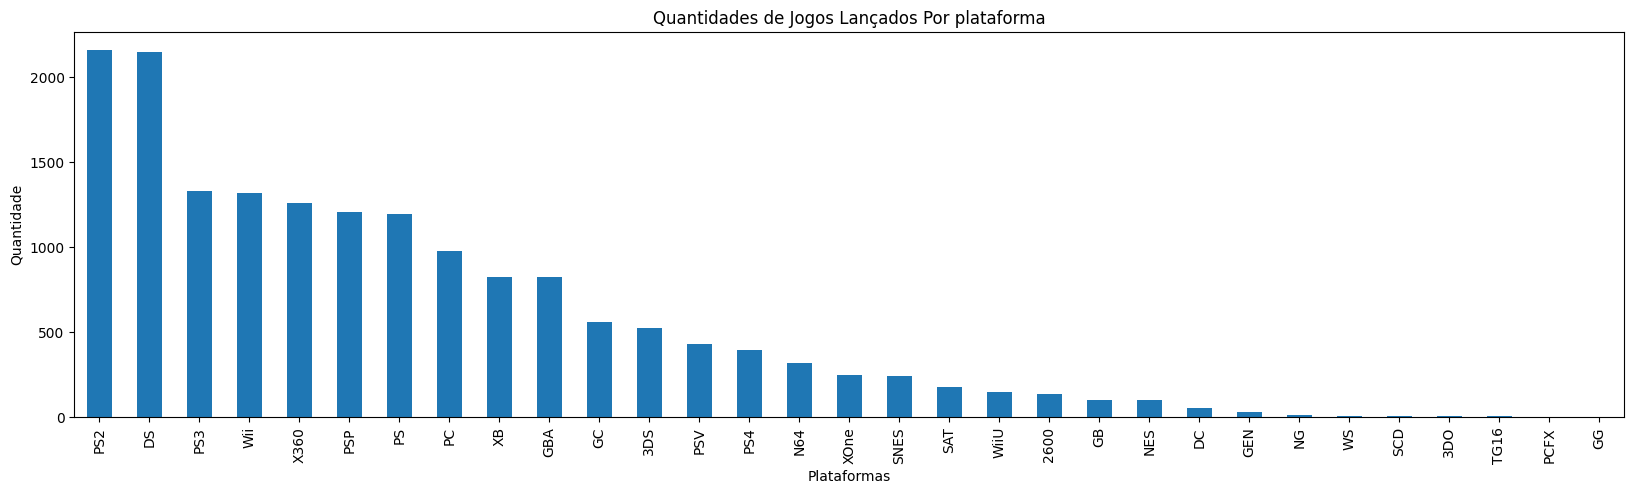

In [21]:
resultado_por_plataforma.plot(title='Quantidades de Jogos Lançados Por plataforma',
               xlabel='Plataformas',
               ylabel='Quantidade',
               figsize=[20, 5],
               kind='bar',                             
              )

PS2 e DS com maiores números absolutos, foram os consoles com maior quantidade de jogos lançados.

PS3, Wii e X360 vem logo atrás dominando o segundo patamar do gráfico, mostra que os concorrentes mantinham uma contancia na atualização do seu catálogo de jogos.

Destaque também para a PS, que mesmo após o ano de 2013 continuou com lançamentos se mantendo junto com outras grandes empresas concorrentes como a Microsoft e Nitendo.

In [22]:
games = games[games['year_of_release'] >= 2013]

In [23]:
ano_2013 = games[games['year_of_release'] >= 2013]
x = ano_2013.groupby(['platform'])['name'].count().sort_values(ascending=False).head(11)
print(x)

platform
PS4     392
PSV     358
PS3     345
3DS     303
XOne    247
PC      189
X360    186
WiiU    115
PSP      67
Wii      23
DS        8
Name: name, dtype: int64


C:\Users\drial\AppData\Local\Temp\ipykernel_18900\167502535.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x = ano_2013.groupby(['platform'])['name'].count().sort_values(ascending=False).head(11)


<Axes: title={'center': 'Quantidades de Jogos Lançados Por plataforma a partir de 2013'}, xlabel='Plataformas', ylabel='Quantidade'>

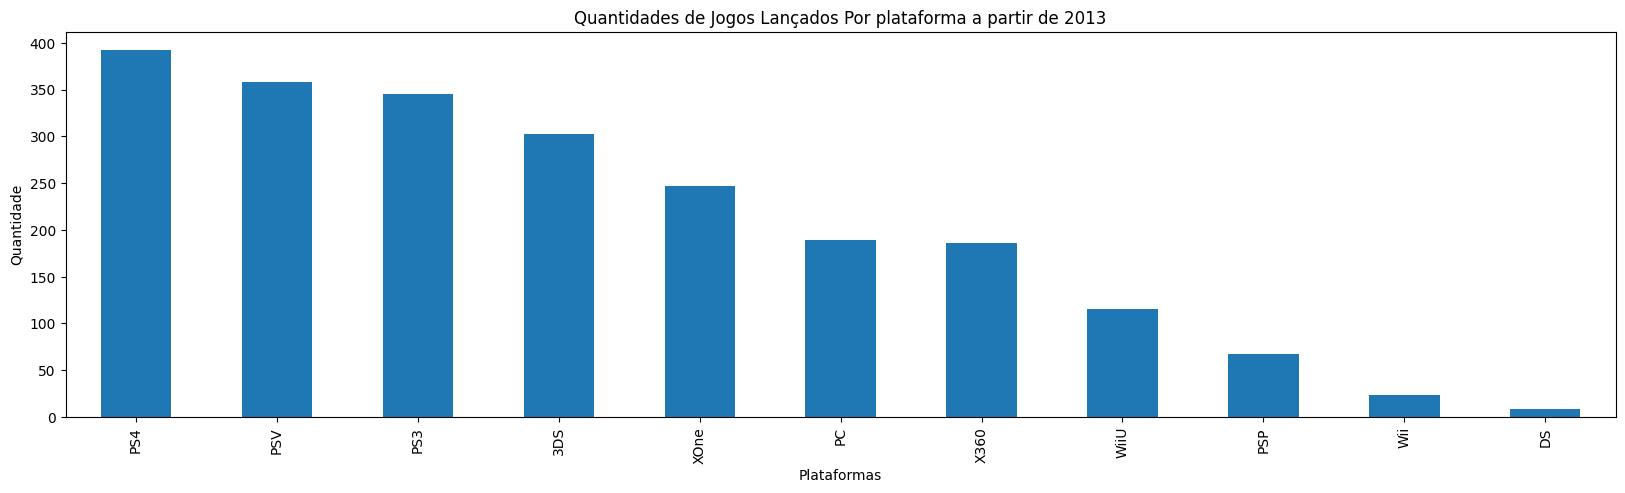

In [24]:
x.plot(title='Quantidades de Jogos Lançados Por plataforma a partir de 2013',
               xlabel='Plataformas',
               ylabel='Quantidade',
               figsize=[20, 5],
               kind='bar',                             
              )

Após o ano de 2013, apenas 11 plataformas continuaram com lançamentos. Os consoles da Sony, apesar da redução no número de lançamentos ainda permancem no rankink

<br><br>

**Vendas por plataforma**

Veja como as vendas variaram de plataforma para plataforma. Escolha as plataformas com as maiores vendas totais e construa uma distribuição com base nos dados para cada ano. Encontre as plataformas que costumavam ser populares, mas que agora não têm vendas. Quanto tempo leva para as novas plataformas aparecerem e as antigas desaparecerem?



platform
PS4     314.14
PS3     181.43
XOne    159.32
Name: total_sales, dtype: float64



C:\Users\drial\AppData\Local\Temp\ipykernel_18900\2824013837.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  vendas_por_plataforma = games.groupby(['platform'])


<Axes: title={'center': 'Rankig de Vendas de Jogos por Plataformas'}, xlabel='Plataformas', ylabel='Quantidade de vendas'>

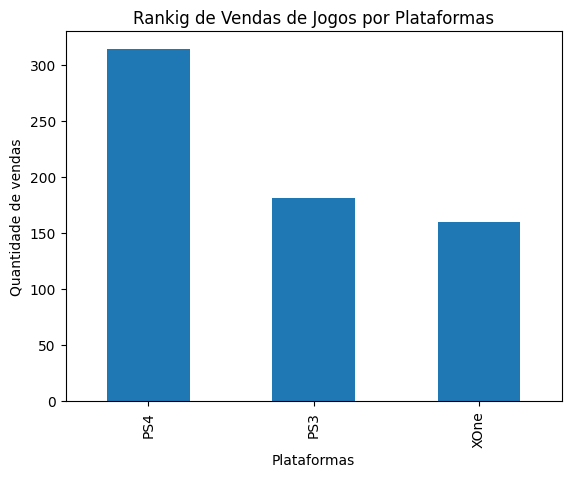

In [25]:
vendas_por_plataforma = games.groupby(['platform'])
resultado_plataforma = vendas_por_plataforma['total_sales'].sum()
ranking = resultado_plataforma.sort_values(ascending=False).head(3)
print(ranking)
print()
ranking.plot(title='Rankig de Vendas de Jogos por Plataformas',
             kind='bar',
             xlabel='Plataformas',
             ylabel='Quantidade de vendas'
            )

In [26]:
# Vendas por ano year_of_release total_sales
ranking_3primeiros = ranking.keys()

# Filtrando apenas dados das 3 platafomas mais vendidas (PS2, X360 e PS3)
ranking_vendas = games.query("platform in @ranking_3primeiros")[['platform', 'year_of_release', 'total_sales']]

# Somando o total de vendas por plataforma por ano e ordenando
z = ranking_vendas.groupby(['platform', 'year_of_release'])['total_sales'].sum()

print(z.loc[ranking_3primeiros].sort_index())

platform  year_of_release
PS3       2013               113.25
          2014                47.76
          2015                16.82
          2016                 3.60
PS4       2013                25.99
          2014               100.00
          2015               118.90
          2016                69.25
XOne      2013                18.96
          2014                54.07
          2015                60.14
          2016                26.15
Name: total_sales, dtype: float64


C:\Users\drial\AppData\Local\Temp\ipykernel_18900\1397306657.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  z = ranking_vendas.groupby(['platform', 'year_of_release'])['total_sales'].sum()


Comparando o desempenho das três plataformas mais vendidas (PS2, X360 e PS3), observa-se que, entre os anos de 2000 e 2007, o mercado foi amplamente dominado pelo PS2. A partir de 2007, a plataforma apresenta uma queda significativa em suas vendas, dando início a uma disputa mais acirrada entre o X360 e o PS3. Embora o X360 tenha iniciado com números de vendas superiores, e o PS3 tenha ultrapassado suas vendas a partir de 2011, o X360 ainda se mantém à frente quando consideradas as vendas totais no período analisado.

<br><br>

**Comparação de geral de vendas por plataforma**

Construa um diagrama de caixa para as vendas globais de todos os jogos, divididos por plataforma. As diferenças nas vendas são significativas? E quanto às vendas médias em várias plataformas? Descreva suas descobertas.

<Figure size 5000x1000 with 0 Axes>

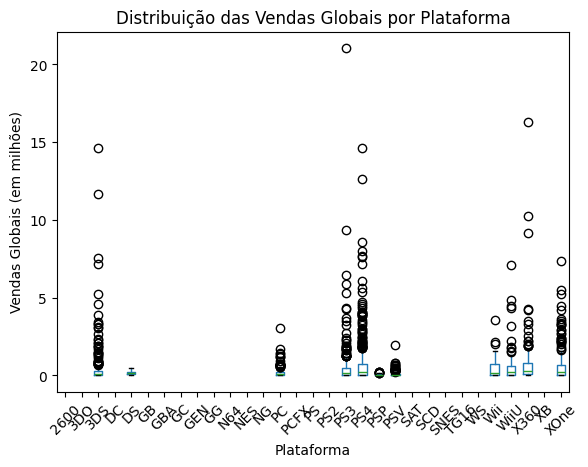

In [27]:
plt.figure(figsize=(50, 10))
games.boxplot(column='total_sales', by='platform', grid=False)
plt.title('Distribuição das Vendas Globais por Plataforma')
plt.suptitle('')  # remove o título automático extra
plt.xlabel('Plataforma')
plt.ylabel('Vendas Globais (em milhões)')
plt.xticks(rotation=45)
plt.show()

In [28]:
# Estatísticas descritivas por plataforma
vendas_stats = games.groupby('platform')['total_sales'].describe()
print(vendas_stats)

# Vendas médias por plataforma
vendas_medias = games.groupby('platform')['total_sales'].mean().sort_values(ascending=False)
print('\nVendas médias por plataforma:')
print(vendas_medias)

          count      mean       std   min     25%    50%     75%    max
platform                                                               
2600        0.0       NaN       NaN   NaN     NaN    NaN     NaN    NaN
3DO         0.0       NaN       NaN   NaN     NaN    NaN     NaN    NaN
3DS       303.0  0.472772  1.381347  0.01  0.0400  0.090  0.2800  14.60
DC          0.0       NaN       NaN   NaN     NaN    NaN     NaN    NaN
DS          8.0  0.192500  0.172026  0.03  0.0675  0.150  0.2525   0.51
GB          0.0       NaN       NaN   NaN     NaN    NaN     NaN    NaN
GBA         0.0       NaN       NaN   NaN     NaN    NaN     NaN    NaN
GC          0.0       NaN       NaN   NaN     NaN    NaN     NaN    NaN
GEN         0.0       NaN       NaN   NaN     NaN    NaN     NaN    NaN
GG          0.0       NaN       NaN   NaN     NaN    NaN     NaN    NaN
N64         0.0       NaN       NaN   NaN     NaN    NaN     NaN    NaN
NES         0.0       NaN       NaN   NaN     NaN    NaN     NaN

C:\Users\drial\AppData\Local\Temp\ipykernel_18900\1576254118.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  vendas_stats = games.groupby('platform')['total_sales'].describe()
C:\Users\drial\AppData\Local\Temp\ipykernel_18900\1576254118.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  vendas_medias = games.groupby('platform')['total_sales'].mean().sort_values(ascending=False)


A tabela apresenta estatísticas descritivas (contagem, média, desvio padrão, valores mínimos, quartis e máximos) das vendas globais (total_sales) agrupadas por plataforma.

Nintendo domina as maiores médias históricas de vendas (GB, NES, SNES), mas PlayStation 4 e Xbox 360 aparecem com ótimos desempenhos entre as plataformas mais recentes.

As piores médias aparecem em: PCFX (0.03), 3DO (0.03), GG (0.04) — plataformas de nicho, pouca base de usuários e poucos jogos lançados.

<br><br>

**Influência das avaliações**

Veja como as avaliações de usuários e profissionais afetam as vendas de uma das plataformas populares (você escolhe). Construa um gráfico de dispersão e calcule a correlação entre avaliações e vendas.



In [29]:
# Filtrando a plataforma PS4 para análise de correlação
ps4 = games[games['platform'] == 'PS4']

# Calcular correlação
#print(ps4['critic_score'].corr(ps4['total_sales']))
corr_critic = ps4['critic_score'].corr(ps4['total_sales'])
corr_user = ps4['user_score'].corr(ps4['total_sales'])

print(f"Correlação (Críticos x Vendas): {corr_critic:.2f}")
print(f"Correlação (Usuários x Vendas): {corr_user:.2f}")

Correlação (Críticos x Vendas): 0.41
Correlação (Usuários x Vendas): -0.03


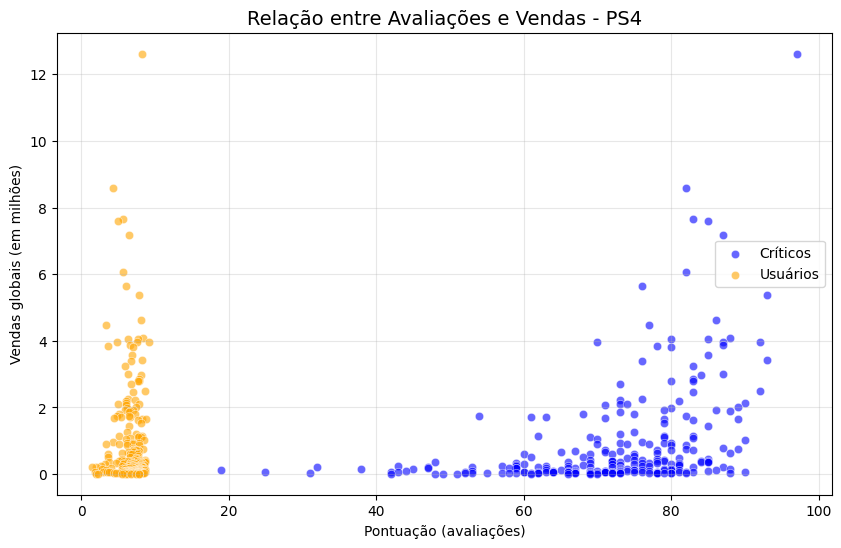

In [30]:
# Criar o gráfico de dispersão
plt.figure(figsize=(10,6))
sns.scatterplot(data=ps4, x='critic_score', y='total_sales', label='Críticos', color='blue', alpha=0.6)
sns.scatterplot(data=ps4, x='user_score', y='total_sales', label='Usuários', color='orange', alpha=0.6)

plt.title('Relação entre Avaliações e Vendas - PS4', fontsize=14)
plt.xlabel('Pontuação (avaliações)')
plt.ylabel('Vendas globais (em milhões)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

***_Avaliações dos críticos - critic_score (0.41)***

Correlação positiva moderada.

Isso significa que jogos do PS4 com notas mais altas dos críticos tendem a vender mais.

O valor 0.41 não é altíssimo, mas indica uma relação real e consistente entre boa avaliação profissional e bom desempenho comercial.

***Avaliações dos usuários - user_score (-0.03)***

Correlação praticamente nula.

As notas dadas pelos jogadores não têm relação com o volume de vendas.
<br><br>
<br><br>
**Comparação de jogos lançados para PS4 em relação as outras plataformas.**

Tendo suas conclusões em mente, compare as vendas dos mesmos jogos em outras plataformas.



In [31]:
# Filtrar apenas os jogos que também existem em outras plataformas
multi = games[games['name'].isin(games[games['platform'] == 'PS4']['name'])].copy()

# Manter apenas colunas relevantes
multi = multi[['name', 'platform', 'total_sales', 'critic_score', 'user_score']]

# Remover valores ausentes
multi = multi.dropna(subset=['total_sales'])

# Calcular média de vendas por jogo e plataforma
media_vendas = multi.groupby(['platform'])['total_sales'].mean().sort_values(ascending=False)

print("Média de vendas dos jogos lançados no PS4 e em outras plataformas:\n")
print(media_vendas)

Média de vendas dos jogos lançados no PS4 e em outras plataformas:

platform
Wii     1.117000
X360    1.072900
PS4     0.801378
PS3     0.771818
XOne    0.596129
DS      0.380000
WiiU    0.329143
3DS     0.289474
PC      0.214476
PSV     0.144512
PSP     0.120000
2600         NaN
3DO          NaN
DC           NaN
GB           NaN
GBA          NaN
GC           NaN
GEN          NaN
GG           NaN
N64          NaN
NES          NaN
NG           NaN
PCFX         NaN
PS           NaN
PS2          NaN
SAT          NaN
SCD          NaN
SNES         NaN
TG16         NaN
WS           NaN
XB           NaN
Name: total_sales, dtype: float64


C:\Users\drial\AppData\Local\Temp\ipykernel_18900\746401361.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  media_vendas = multi.groupby(['platform'])['total_sales'].mean().sort_values(ascending=False)


**Análise do comparativo**

Comparando as vendas dos mesmos jogos do PS4 em outras plataformas, observa-se que os títulos da Sony costumam apresentar melhor desempenho comercial em seu próprio console, seguidos de perto pelo Xbox One.

No PC e em plataformas anteriores, as vendas são menores. Essa diferença indica que, mesmo que o jogo ofereça uma boa qualidade de acordo com as avaliações, o desempenho comercial depende fortemente da base de jogadores e do ciclo de vida da plataforma.

<br><br>

**Distribuição geral de jogos por gênero**

Dê uma olhada na distribuição geral de jogos por gênero. O que podemos dizer sobre os gêneros mais lucrativos? Você pode generalizar sobre gêneros com vendas altas e baixas?



genre
Action          766
Role-Playing    292
Adventure       245
Sports          214
Shooter         187
Misc            155
Racing           85
Fighting         80
Platform         74
Simulation       62
Strategy         56
Puzzle           17
Name: count, dtype: int64
genre
Shooter         1.245882
Sports          0.703972
Platform        0.576081
Role-Playing    0.499623
Racing          0.469294
Fighting        0.441375
Action          0.420196
Misc            0.405290
Simulation      0.350968
Puzzle          0.186471
Strategy        0.180000
Adventure       0.096490
Name: total_sales, dtype: float64
genre
Action          321.87
Shooter         232.98
Sports          150.65
Role-Playing    145.89
Misc             62.82
Platform         42.63
Racing           39.89
Fighting         35.31
Adventure        23.64
Simulation       21.76
Strategy         10.08
Puzzle            3.17
Name: total_sales, dtype: float64


C:\Users\drial\AppData\Local\Temp\ipykernel_18900\803336790.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  genre_mean_sales = genre_sales.groupby('genre')['total_sales'].mean().sort_values(ascending=False)
C:\Users\drial\AppData\Local\Temp\ipykernel_18900\803336790.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  genre_total_sales = genre_sales.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
C:\Users\drial\AppData\Local\Temp\ipykernel_18900\803336790.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variab

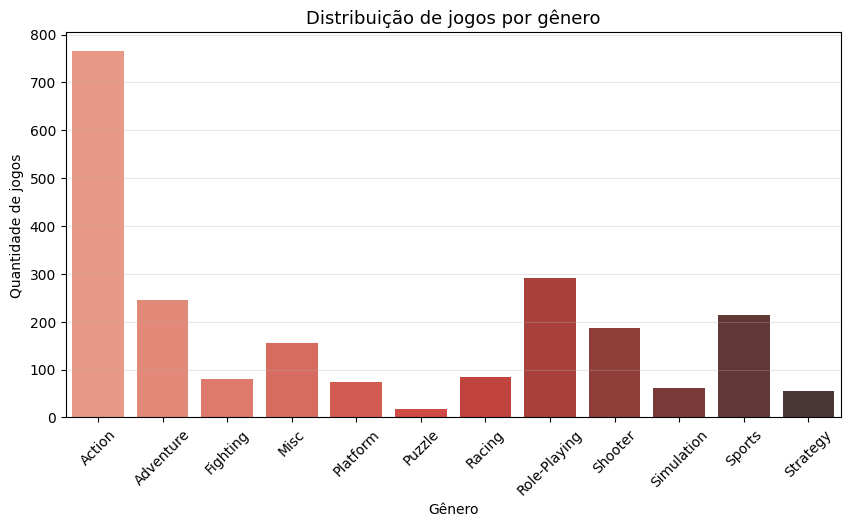

C:\Users\drial\AppData\Local\Temp\ipykernel_18900\803336790.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_total_sales.index, y=genre_total_sales.values, palette="Blues_d")


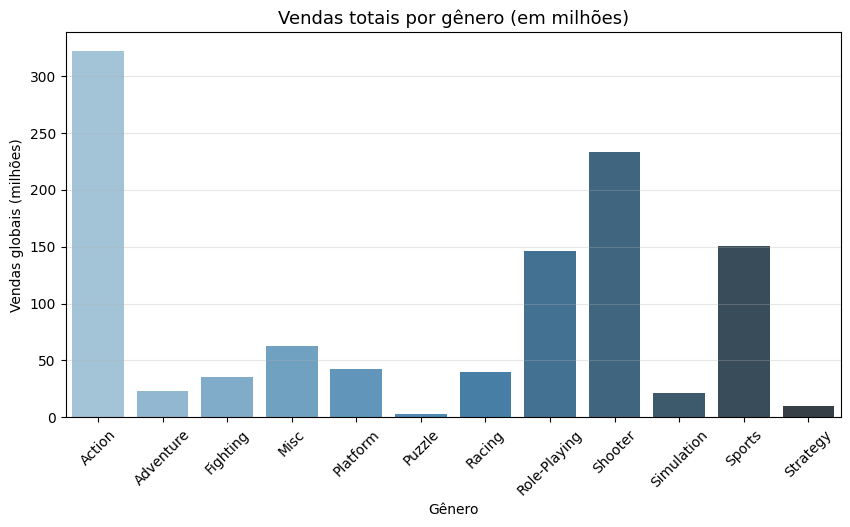

In [32]:
# Remover valores ausentes em 'genre' e 'total_sales'
genre_sales = games.dropna(subset=['genre', 'total_sales'])

# Contagem de jogos por gênero
genre_count = genre_sales['genre'].value_counts()
print(genre_count)

# Vendas médias por gênero
genre_mean_sales = genre_sales.groupby('genre')['total_sales'].mean().sort_values(ascending=False)
print(genre_mean_sales)

# Vendas totais por gênero
genre_total_sales = genre_sales.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
print(genre_total_sales)

# Quantidade de jogos por gênero
plt.figure(figsize=(10,5))
sns.barplot(x=genre_count.index, y=genre_count.values, palette="Reds_d")
plt.title("Distribuição de jogos por gênero", fontsize=13)
plt.ylabel("Quantidade de jogos")
plt.xlabel("Gênero")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

# Gêneros que mais venderam
plt.figure(figsize=(10,5))
sns.barplot(x=genre_total_sales.index, y=genre_total_sales.values, palette="Blues_d")
plt.title("Vendas totais por gênero (em milhões)", fontsize=13)
plt.ylabel("Vendas globais (milhões)")
plt.xlabel("Gênero")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

**Distribuição geral de jogos por gênero** -  A análise da distribuição de jogos por gênero revela que os títulos de ação, tiro e esportes são os mais representativos e lucrativos da indústria. Esses gêneros combinam alto volume de lançamentos com vendas expressivas, impulsionadas por franquias de sucesso e campanhas de marketing robustas. Em contrapartida, gêneros como quebra-cabeça, estratégia e simulação apresentam desempenho comercial mais modesto, refletindo um público mais restrito. Já os RPGs e aventuras demonstram boa lucratividade média, sustentada por franquias consolidadas e comunidades fiéis.

<br><br>

# Etapa 4 - Criação de perfil de usuário para cada região

Para cada região (AN, UE, JP), determine:
- As cinco plataformas principais. Descreva as variações das suas quotas de mercado de região para região.
- Os cinco principais gêneros. Explique a diferença.
- As classificações do ESRB afetam as vendas em regiões individuais?

**Top Vendas - plataformas**


In [33]:
# Top 5 (NA)
top5_na = games.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head(5)

# Top 5 (EU)
top5_eu = games.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).head(5)

# Top 5 (JP)
top5_jp = games.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).head(5)



top5_na, top5_eu, top5_jp

C:\Users\drial\AppData\Local\Temp\ipykernel_18900\3432790553.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top5_na = games.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head(5)
C:\Users\drial\AppData\Local\Temp\ipykernel_18900\3432790553.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top5_eu = games.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).head(5)
C:\Users\drial\AppData\Local\Temp\ipykernel_18900\3432790553.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to 

(platform
 PS4     108.74
 XOne     93.12
 X360     81.66
 PS3      63.50
 3DS      38.20
 Name: na_sales, dtype: float64,
 platform
 PS4     141.09
 PS3      67.81
 XOne     51.59
 X360     42.52
 3DS      30.96
 Name: eu_sales, dtype: float64,
 platform
 3DS     67.81
 PS3     23.35
 PSV     18.59
 PS4     15.96
 WiiU    10.88
 Name: jp_sales, dtype: float64)

In [34]:
# Calcular percentuais de mercado
na_total = games['na_sales'].sum()
eu_total = games['eu_sales'].sum()
jp_total = games['jp_sales'].sum()

quota_na = (top5_na / na_total * 100).round(2)
quota_eu = (top5_eu / eu_total * 100).round(2)
quota_jp = (top5_jp / jp_total * 100).round(2)

# Unir em um único DataFrame para comparação
quota_df = pd.concat([quota_na, quota_eu, quota_jp], axis=1)
quota_df.columns = ['NA_%', 'EU_%', 'JP_%']

print(quota_df)

           NA_%   EU_%   JP_%
platform                     
PS4       24.84  35.97  11.34
XOne      21.27  13.15    NaN
X360      18.66  10.84    NaN
PS3       14.51  17.29  16.59
3DS        8.73   7.89  48.17
PSV         NaN    NaN  13.21
WiiU        NaN    NaN   7.73


**NA -** Liderada pela X360 - 13,69% (Microsoft) e seguida pela PS2 - 13,27% (SONY)

**EU -** Na Europa quem lidera são consoles da SONY, PS2 - 14% em 1°, seguida da PS3 - 13,63% em 2°

**JP -** Já no Japão, tem DS liderando o mercado com 13,53%, seguida dos consoles da SONY PS e PS2, com 10,78% e 10,73% respectivamente.

<br><br>

**Top Vendas - gêneros**


In [35]:
# Participação percentual
quota_genre_na = (games.groupby('genre')['na_sales'].sum() / games['na_sales'].sum() * 100).sort_values(ascending=False)
quota_genre_eu = (games.groupby('genre')['eu_sales'].sum() / games['eu_sales'].sum() * 100).sort_values(ascending=False)
quota_genre_jp = (games.groupby('genre')['jp_sales'].sum() / games['jp_sales'].sum() * 100).sort_values(ascending=False)

# Combinar
quota_genre_df = pd.concat([quota_genre_na, quota_genre_eu, quota_genre_jp], axis=1)
quota_genre_df.columns = ['NA_%', 'EU_%', 'JP_%']

print(quota_genre_df)

                   NA_%       EU_%       JP_%
genre                                        
Action        28.797606  30.117533  28.761188
Shooter       25.071394  22.400122   4.695269
Sports        14.911700  15.429722   3.842875
Role-Playing  10.600626   9.425592  36.255150
Misc           6.280414   5.109247   6.535019
Platform       4.144296   3.972159   3.402472
Fighting       3.552580   2.179843   5.434011
Racing         2.960864   5.147490   1.633755
Adventure      1.631217   2.103358   4.134110
Simulation     1.110324   2.784081   3.210683
Strategy       0.749355   1.075899   1.257281
Puzzle         0.189623   0.254952   0.838187


C:\Users\drial\AppData\Local\Temp\ipykernel_18900\2465365945.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quota_genre_na = (games.groupby('genre')['na_sales'].sum() / games['na_sales'].sum() * 100).sort_values(ascending=False)
C:\Users\drial\AppData\Local\Temp\ipykernel_18900\2465365945.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quota_genre_eu = (games.groupby('genre')['eu_sales'].sum() / games['eu_sales'].sum() * 100).sort_values(ascending=False)
C:\Users\drial\AppData\Local\Temp\ipykernel_18900\2465365945.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to

**NA -** Ranking: Action (19,97%), Sports (15,55%) e Shooter (13,46%).

**EU -** Ranking: Action (21,42%), Sports (15,54%) e Shooter (13,46%).

**JP -** Ranking: Role-Playing (27,4%), Action (12,44%) e Sports (13,46%).

<br><br>

**Influência das Classificações ESRB nas Vendas por Região**


In [36]:
# Somar vendas por classificação em cada região
rating_sales = games.groupby('rating')[['na_sales', 'eu_sales', 'jp_sales']].sum()

# Calcular participação percentual dentro de cada região
rating_share = rating_sales.div(rating_sales.sum(axis=0), axis=1) * 100

rating_share.round(2)

C:\Users\drial\AppData\Local\Temp\ipykernel_18900\470313467.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating_sales = games.groupby('rating')[['na_sales', 'eu_sales', 'jp_sales']].sum()


,na_sales,eu_sales,jp_sales
rating,,,
AO,0.00,0.00,0.00
E,18.06,21.25,10.75
E10+,12.39,10.88,4.18
EC,0.00,0.00,0.00
K-A,0.00,0.00,0.00
M,37.74,37.05,10.02
RP,0.00,0.00,0.00
T,11.38,10.70,14.63
Unknown,20.43,20.12,60.41


Sim, as classificações ESRB afetam significativamente as vendas regionais.

Nos mercados ocidentais (NA/EU), jogos com classificação T e M vendem muito bem.

Já no Japão, há uma preferência marcante por jogos E (Everyone), com menor aceitação de títulos violentos.

<br><br>

# Etapa 5 - Teste de hipóteses

As classificações médias dos usuários das plataformas Xbox One e PC são as mesmas.

- H0 (nula) - As médias das plataformas Xbox One e PC são iguais
- H1 (alternativa) - As médias das plataformas Xbox One e PC são diferentes



In [37]:
# Selecionar as amostras
sample_xone = games.loc[games['platform'] == 'XOne', 'user_score'].dropna()
sample_pc = games.loc[games['platform'] == 'PC', 'user_score'].dropna()

# Calcular as variâncias amostrais
var_xone = sample_xone.var(ddof=1)
var_pc = sample_pc.var(ddof=1)

print(f'Variância (Xbox One): {var_xone:.2f}')
print(f'Variância (PC): {var_pc:.2f}')

equal_var_resul = var_xone == var_pc
print("As variâncias são exatamente iguais?", equal_var_resul)
print()

# Teste t
stat, p_val = stats.ttest_ind(sample_xone, sample_pc, equal_var=equal_var_resul)

print(f'Estatística t = {stat:.2f}')
print(f'p-valor = {p_val:.4f}')

alpha = 0.05
if p_val > alpha:
    print('Não rejeitamos H0 → As médias são consideradas iguais.')
else:
    print('Rejeitamos H0 → As médias são diferentes.')

Variância (Xbox One): 1.91
Variância (PC): 3.04
As variâncias são exatamente iguais? False

Estatística t = 1.45
p-valor = 0.1476
Não rejeitamos H0 → As médias são consideradas iguais.


As classificações médias de usuários para os gêneros Action (ação) e Sports (esportes) são diferentes.

H0 (nula) - As médiasde usuários para os gêneros Action (ação) e Sports (esportes) são iguais.

H1 (alterntiva) - As médias de usuários para os gêneros Action (ação) e Sports (esportes) são diferentes.



In [38]:
# Selecionar amostras
sample_action = games.loc[games['genre'] == 'Action', 'user_score'].dropna()
sample_sports = games.loc[games['genre'] == 'Sports', 'user_score'].dropna()

# Calcular as variâncias amostrais
var_action = sample_action.var(ddof=1)
var_sports = sample_sports.var(ddof=1)

print(f'Variância (Action): {var_action:.2f}')
print(f'Variância (Sports): {var_sports:.2f}')

equal_var_result = var_action == var_sports
print("As variâncias são exatamente iguais?", equal_var_result)
print()

# Teste t
stat, p_val = stats.ttest_ind(sample_action, sample_sports, equal_var=equal_var_result)

print(f'Estatística t = {stat:.2f}')
print(f'p-valor = {p_val:.2f}')

alpha = 0.05
if p_val > alpha:
    print('Não rejeitamos H0 → As médias das avaliações são consideradas iguais.')
else:
    print('Rejeitamos H0 → As médias das avaliações são diferentes.')

Variância (Action): 1.77
Variância (Sports): 3.18
As variâncias são exatamente iguais? False

Estatística t = 10.23
p-valor = 0.00
Rejeitamos H0 → As médias das avaliações são diferentes.


**QUESTÕES**

Defina por conta própria o valor do limiar alfa.

Explique:

— Como você formulou as hipóteses alternativas e nulas?

— Qual o nível de significância que você escolheu para testar as hipóteses, e por quê?



**RESPOSTAS**


Para cada comparação (Xbox One × PC; Action × Sports) usei a mesma lógica:

Hipótese nula (H₀): as médias das classificações de usuários são iguais.

Hipótese alternativa (H₁): as médias são diferentes (não especificamos direção).

Justificativa: você pediu para testar se as médias são diferentes (não “maior/menor”), então usamos teste bilateral (two-tailed). Isso é apropriado quando não há uma hipótese direcional prévia confiável.


Hipóteses: 𝐻0:𝜇𝐴=𝜇𝐵 vs 𝐻1:𝜇𝐴≠𝜇𝐵 (teste bilateral).


Nível de significância. alpha=0,05

É o padrão amplamente usado em ciências sociais e análise exploratória de dados

Representa uma probabilidade de 5% de cometer um erro tipo I (rejeitar H₀ quando H₀ é verdadeira), o que costuma ser aceitável para estudos não-críticos.

<br><br>

# Etapa 6 - Conclusão geral

1. Distribuição temporal dos lançamentos

    - Observou-se um crescimento acentuado no número de lançamentos entre 2001 e 2011, com o auge entre 2008 e 2010.

    - A partir de 2012, há queda contínua no volume de jogos lançados. O ciclo de vida dos consoles tem forte impacto na quantidade de lançamentos, e a migração para o digital alterou o padrão histórico dos dados.

2. Diferenças regionais nas vendas

    - As plataformas mais vendidas variam conforme a região:

    - América do Norte (NA): domínio das plataformas da Microsoft (X360, XOne).

    - Europa (EU): destaque para PlayStation (PS2, PS3, PS4).

    - Japão (JP): preferência clara por plataformas Nintendo (3DS, DS, Wii), com um disparo sobre os jogos do gênero Role-Playing com 27,4% das vendas.

    - O comportamento regional é fortemente influenciado pela origem e preferência cultural das empresas locais. O mercado japonês, em especial, tem perfil distinto.

3. Gêneros mais lucrativos

    - Ação (Action), Esportes (Sports) e Tiro (Shooter) concentram grande parte das vendas globais.

    - Gêneros como Puzzle, Strategy e Adventure apresentam vendas bem menores, embora alguns tenham avaliações altas.

    - Gêneros mais populares comercialmente nem sempre são os mais bem avaliados pelos usuários; eles dominam o mercado por apelo de massa e franquias estabelecidas.

4. Classificações ESRB e impacto nas vendas

    - As classificações E (Everyone) e T (Teen) tendem a ter melhor desempenho em vendas, especialmente na América do Norte.

    - Jogos M (Mature), embora comuns em gêneros como ação e tiro, vendem bem apenas em regiões específicas.

    - A faixa etária permitida pode influenciar o alcance de público e, consequentemente, as vendas.

5. Considerações finais

    - As diferenças regionais e de gênero são fortemente marcadas por preferências culturais e ciclos tecnológicos.

    - As classificações dos usuários não dependem fortemente da plataforma, mas variam por gênero e estilo de jogo.

    - O mercado de videogames mostra comportamento cíclico com picos em lançamentos de novos consoles.

    - O teste estatístico confirmou que nem todas as percepções visuais (diferenças aparentes nos gráficos) são realmente significativas quando analisadas estatisticamente.

    - O DataFrame revela que o sucesso de vendas e a avaliação dos usuários dependem mais de gênero e região do que de plataforma, e que diferenças observadas visualmente nem sempre são confirmadas estatisticamente.



